# Loan Dataset – EDA & Credit Risk Analysis

**Objective:**  
Perform structured EDA on loan data to understand default drivers, define KPIs, and generate business-ready insights.

**Dataset:** loan_data(best).csv

In [1]:
# Cell 1 — always run this first
import sys
!{sys.executable} -m pip install -r requirements.txt

import os
# Create directory if it doesn't exist
os.makedirs('./output', exist_ok=True)

In [2]:
import pandas as pd

df = pd.read_csv('loan_data(best).csv')

print(df.shape)           # how many rows, columns?
print(df.dtypes)          # what type is each column?
print(df.isnull().sum())  # any missing values?
print(df.describe())      # stats for numerical columns
print(df['loan_status'].value_counts())  # is the target balanced?


(45000, 14)
person_age                          int64
person_gender                      object
person_education                   object
person_income                       int64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                           int64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length          int64
credit_score                        int64
previous_loan_defaults_on_file     object
loan_status                         int64
dtype: object
person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length

In [3]:
cat_cols = ['person_gender', 'person_education', 
            'person_home_ownership', 'loan_intent', 
            'previous_loan_defaults_on_file']

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


person_gender:
person_gender
male      24841
female    20159
Name: count, dtype: int64

person_education:
person_education
Bachelor       13399
Associate      12028
High School    11972
Master          6980
Doctorate        621
Name: count, dtype: int64

person_home_ownership:
person_home_ownership
RENT        23443
MORTGAGE    18489
OWN          2951
OTHER         117
Name: count, dtype: int64

loan_intent:
loan_intent
EDUCATION            9153
MEDICAL              8548
VENTURE              7819
PERSONAL             7552
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64

previous_loan_defaults_on_file:
previous_loan_defaults_on_file
Yes    22858
No     22142
Name: count, dtype: int64


In [4]:
print(df[['person_age', 'person_income', 
          'person_emp_exp', 'credit_score']].describe())


         person_age  person_income  person_emp_exp  credit_score
count  45000.000000   4.500000e+04    45000.000000  45000.000000
mean      27.764178   8.031905e+04        5.410333    632.608756
std        6.045108   8.042250e+04        6.063532     50.435865
min       20.000000   8.000000e+03        0.000000    390.000000
25%       24.000000   4.720400e+04        1.000000    601.000000
50%       26.000000   6.704800e+04        4.000000    640.000000
75%       30.000000   9.578925e+04        8.000000    670.000000
max      144.000000   7.200766e+06      125.000000    850.000000


person_age max = 144.
Impossible.Someone entered garbage data or there's a data entry error. The 75th percentile is 30, so this is almost certainly an outlier, not a real age range.

person_emp_exp max = 125 years. 
Also impossible. No one has 125 years of work experience. Same problem.

person_income max = 7.2 million 
with a mean of 80k. Could be real (a few high earners), could be an error. Needs investigation.

In [5]:
print("Ages over 100:", (df['person_age'] > 100).sum())
print("Ages over 80:",  (df['person_age'] > 80).sum())

print("\nEmp exp over 60:", (df['person_emp_exp'] > 60).sum())
print("Emp exp over 40:", (df['person_emp_exp'] > 40).sum())

print("\nIncome over 1M:", (df['person_income'] > 1_000_000).sum())
print("Income over 500k:", (df['person_income'] > 500_000).sum())

# Also: does age make sense relative to emp experience?
# You can't be 22 with 15 years of experience
df['age_exp_gap'] = df['person_age'] - df['person_emp_exp']
print("\nRows where emp_exp >= age:", (df['age_exp_gap'] <= 0).sum())

Ages over 100: 7
Ages over 80: 9

Emp exp over 60: 10
Emp exp over 40: 65

Income over 1M: 24
Income over 500k: 104

Rows where emp_exp >= age: 0


Age over 100: only 7 rows out of 45,000. 
That's 0.015% of your data. Almost certainly typos — someone typed 144 instead of 44, or 122 instead of 22. Not worth trying to recover. Drop them.

Emp exp over 60: only 10 rows. 
Same logic. A 125-year career doesn't exist. Drop them.

Income over 1M: 24 rows. 
This one is different — millionaires exist. But 7.2M with a dataset mean of 80k is suspicious enough to investigate before deciding. Could be real, could be a data entry error (extra zero).

The age_exp_gap > 0 result is actually reassuring — no one has more experience than their age, so the logical relationship holds. The outliers are isolated errors, not systematic problems.

The principle you just learned:

A few bad rows in a large dataset → drop them. If it were 5,000 rows out of 45,000, you'd need a different strategy. Scale determines your response.

In [6]:
# Store original size
original_size = len(df)

# Drop impossible ages and experience
df = df[df['person_age'] <= 100]
df = df[df['person_emp_exp'] <= 60]

# For income: cap extreme outliers at 99th percentile (not drop)
income_cap = df['person_income'].quantile(0.99)
print(f"99th percentile income: {income_cap:,.0f}")
df = df[df['person_income'] <= income_cap]

# Drop the helper column we made
df = df.drop(columns=['age_exp_gap'])

# Verify
print(f"\nRows removed: {original_size - len(df)}")
print(f"Rows remaining: {len(df)}")
print(f"\nNew age range: {df['person_age'].min()} – {df['person_age'].max()}")
print(f"New exp range: {df['person_emp_exp'].min()} – {df['person_emp_exp'].max()}")
print(f"New income range: {df['person_income'].min():,.0f} – {df['person_income'].max():,.0f}")

99th percentile income: 271,269

Rows removed: 460
Rows remaining: 44540

New age range: 20 – 78
New exp range: 0 – 58
New income range: 8,000 – 271,262


why do you think capping is better than dropping for income specifically?

becoz bycapping we are not lossing the original dataset for other columns, like we would have if we dropped all rows

Capping preserves the row — all the other columns (credit score, loan amount, employment history) stay in your dataset. Dropping would throw away valid information just because one column had an extreme value.

The income gets "trimmed" to a realistic ceiling, everything else survives.

That's the core intuition: only discard a row when the entire row is untrustworthy. A typo age of 144 poisons the whole record. An extreme income just needs a ceiling.


In [7]:
cat_cols = ['person_gender', 'person_education', 
            'person_home_ownership', 'loan_intent', 
            'previous_loan_defaults_on_file']

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


person_gender:
person_gender
male      24583
female    19957
Name: count, dtype: int64

person_education:
person_education
Bachelor       13267
Associate      11896
High School    11855
Master          6913
Doctorate        609
Name: count, dtype: int64

person_home_ownership:
person_home_ownership
RENT        23366
MORTGAGE    18137
OWN          2923
OTHER         114
Name: count, dtype: int64

loan_intent:
loan_intent
EDUCATION            9086
MEDICAL              8465
VENTURE              7736
PERSONAL             7465
DEBTCONSOLIDATION    7067
HOMEIMPROVEMENT      4721
Name: count, dtype: int64

previous_loan_defaults_on_file:
previous_loan_defaults_on_file
Yes    22594
No     21946
Name: count, dtype: int64


Are there typos or inconsistent casing? (Male vs male vs MALE)
No

Are there unexpected categories? Something that shouldn't exist
No

Does previous_loan_defaults_on_file contain Yes/No or something else?
yes/No

Any category with very few rows? (under ~100 is worth flagging)
No

## EDA
Phase 1 

Cleaned outliers, explored distributions

Visualised 7 charts, wrote findings

Learned: skew, correlation, boxplots

* Identified impossible values through .describe()
* Dropped 17 rows with bad age/experience data
* Capped income at 99th percentile, preserving 443 rows
* Verified categoricals are clean
* Found one column needing encoding later

Visualising

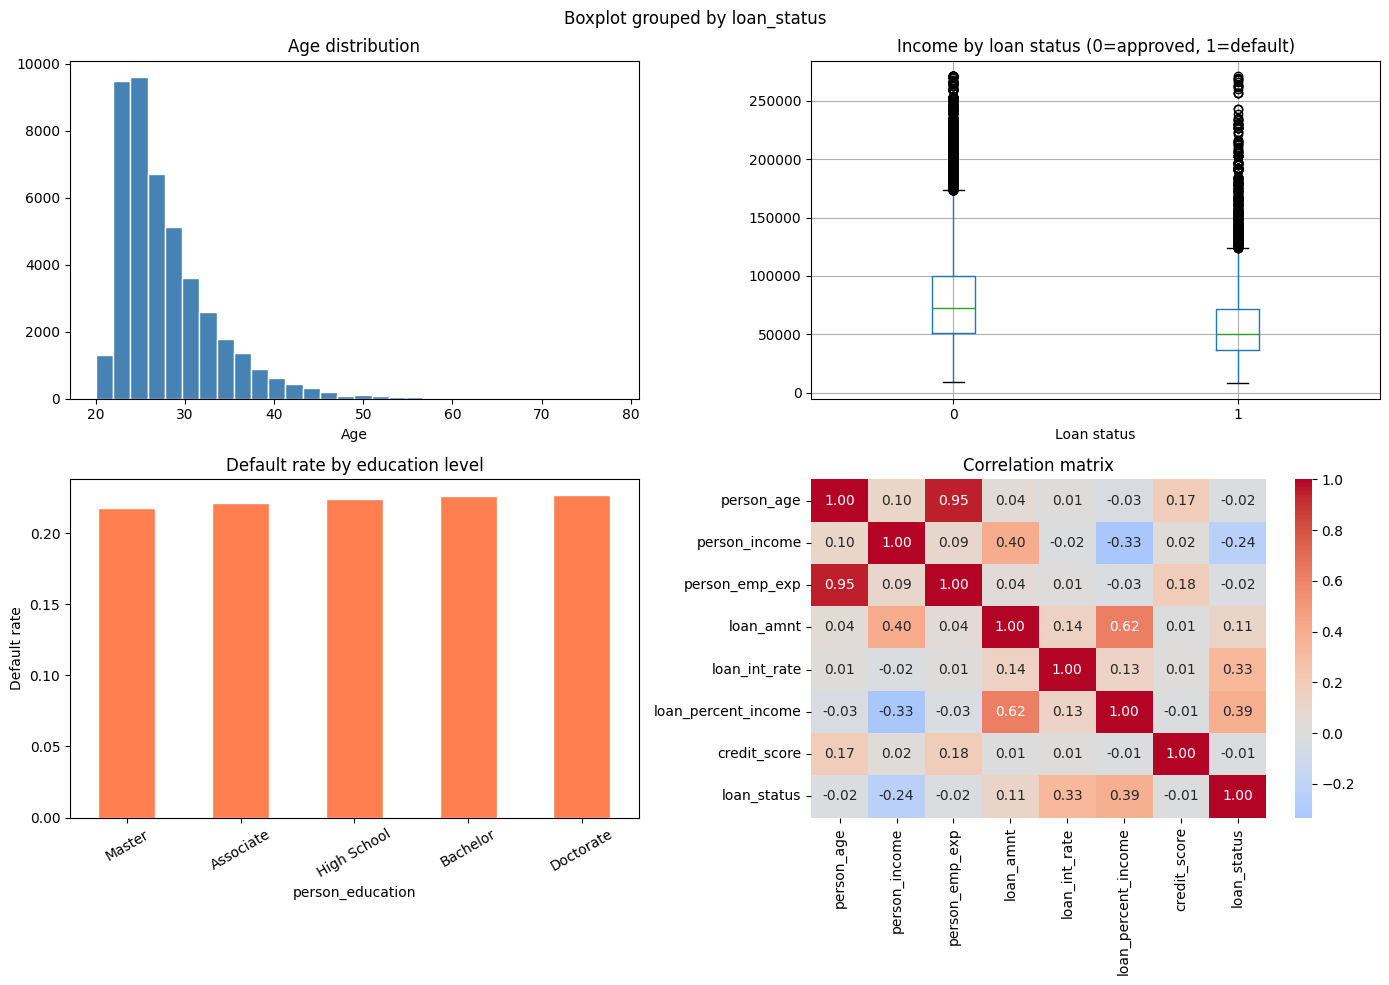

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Loan Dataset — EDA Overview', fontsize=16)

# 1. Age distribution
axes[0,0].hist(df['person_age'], bins=30, color='steelblue', edgecolor='white')
axes[0,0].set_title('Age distribution')
axes[0,0].set_xlabel('Age')

# 2. Income by loan status
df.boxplot(column='person_income', by='loan_status', ax=axes[0,1])
axes[0,1].set_title('Income by loan status (0=approved, 1=default)')
axes[0,1].set_xlabel('Loan status')

# 3. Default rate by education
edu_default = df.groupby('person_education')['loan_status'].mean().sort_values()
edu_default.plot(kind='bar', ax=axes[1,0], color='coral', edgecolor='white')
axes[1,0].set_title('Default rate by education level')
axes[1,0].set_ylabel('Default rate')
axes[1,0].tick_params(axis='x', rotation=30)

# 4. Correlation heatmap
num_cols = ['person_age','person_income','person_emp_exp',
            'loan_amnt','loan_int_rate','loan_percent_income',
            'credit_score','loan_status']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            ax=axes[1,1], center=0)
axes[1,1].set_title('Correlation matrix')

plt.tight_layout()
plt.savefig('./output/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

Is the age distribution skewed or roughly normal?
- Skewed to 20-30

Does income seem to differ between approved and defaulted loans?
- Yes by about 50K

Which numeric column correlates most strongly with loan_status?
- Loan_percent_income

Age is right-skewed — most borrowers are young (20s), which makes sense for a loan dataset. Young people borrow more. This also means your model will have seen far more young borrowers than old ones during training — worth remembering.

Income difference is real and meaningful. Approved borrowers (0) earn ~75k median, defaulters (1) earn ~50k. Lower income → higher default risk. Your hypothesis from Day 1 was right. But notice the boxes overlap heavily — income alone won't predict default. It's a signal, not a rule.

loan_percent_income at 0.39 is your strongest predictor. This makes intuitive sense — it's not how much you earn, it's how much of your income the loan consumes. Someone earning 30k taking a 25k loan is far riskier than someone earning 200k taking the same loan.

One thing you should have noticed but might have missed:

Look at the education chart. All bars are nearly identical height — ~22% default rate regardless of education level. That's a finding too. Education doesn't predict default in this dataset. A feature that shows no variation across your target is a weak predictor. In Phase 2, it may not help your model much.

Also notice person_age and person_emp_exp correlate at 0.95. That's near-perfect. They're basically measuring the same thing. In ML, keeping both causes a problem called multicollinearity. You'll deal with this in Phase 2.

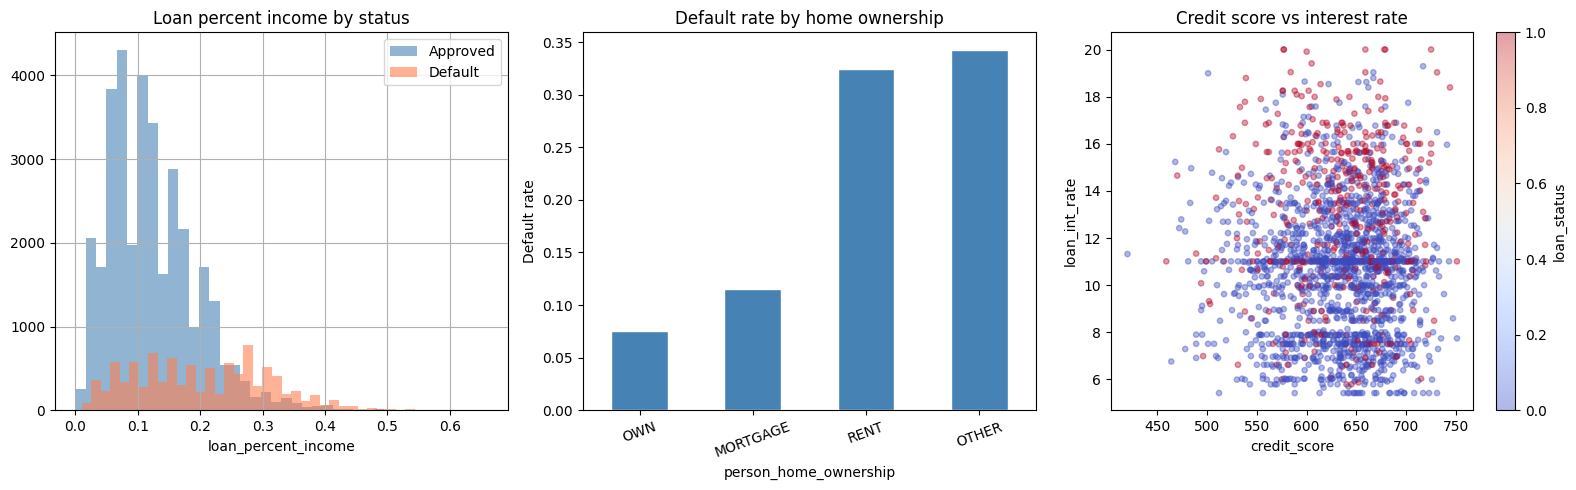

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Does loan_percent_income distribution differ by loan status?
df[df['loan_status']==0]['loan_percent_income'].hist(
    bins=40, alpha=0.6, label='Approved', ax=axes[0], color='steelblue')
df[df['loan_status']==1]['loan_percent_income'].hist(
    bins=40, alpha=0.6, label='Default', ax=axes[0], color='coral')
axes[0].set_title('Loan percent income by status')
axes[0].set_xlabel('loan_percent_income')
axes[0].legend()

# 2. Default rate by home ownership
home_default = df.groupby('person_home_ownership')['loan_status'].mean()
home_default.sort_values().plot(kind='bar', ax=axes[1], 
                                 color='steelblue', edgecolor='white')
axes[1].set_title('Default rate by home ownership')
axes[1].set_ylabel('Default rate')
axes[1].tick_params(axis='x', rotation=20)

# 3. Interest rate vs credit score — coloured by loan status
sample = df.sample(2000, random_state=42)  # sample to avoid overplotting
scatter = axes[2].scatter(sample['credit_score'], sample['loan_int_rate'],
                          c=sample['loan_status'], cmap='coolwarm', 
                          alpha=0.4, s=15)
axes[2].set_title('Credit score vs interest rate')
axes[2].set_xlabel('credit_score')
axes[2].set_ylabel('loan_int_rate')
plt.colorbar(scatter, ax=axes[2], label='loan_status')

plt.tight_layout()
plt.savefig('./output/eda_deep.png', dpi=150, bbox_inches='tight')
plt.show()

Where does loan_percent_income separate approved vs default most clearly — low values or high values?
- low, mostly 0.05-0.1

Do renters default more than homeowners? Does that surprise you?
- yes, no

Do defaulters (red dots) cluster at high or low credit scores?
- middle more like 650

Chart 1 — loan_percent_income

You said "low values" but look again more carefully. At 0.05–0.1 both bars are tall — approved and default borrowers exist there in large numbers. The real separation happens on the right tail. Beyond 0.2, the orange (default) bar barely shrinks while the blue (approved) bar drops sharply. Defaulters keep appearing at high loan_percent_income values where almost no approved borrowers exist. The separation is clearest at high values, not low. Low values just have more of everyone.
The insight: borrowing more than 20% of your income is a strong warning sign.

Chart 2 — home ownership

Your answer is right. OWN = 8% default rate, MORTGAGE = 11%, RENT = 32%, OTHER = 34%. That's a massive jump. Why aren't you surprised? Think about it for a second — owning a home signals stability, assets, financial history. Renters have none of that collateral. The bank is taking a bigger risk. This is actually one of the strongest categorical signals in your dataset.

Chart 3 — credit score scatter

Your answer needs refinement. You said "middle, around 650" — but look at where the red dots concentrate vs blue dots. Red (default) dots appear across the full range, but blue (approved) dots are denser at higher credit scores (700+). More importantly, notice the horizontal bands at certain interest rates — that's the bank clustering loans into rate tiers. The scatter isn't clean enough to be a strong visual separator, which matches what the correlation matrix told you: credit_score only correlated at -0.01 with loan_status. Weak predictor.

### Key Findings

1. **loan_percent_income is the strongest default predictor (r=0.39).**
   Borrowers taking loans above 20% of their income default at significantly
   higher rates. This should be the primary feature in any credit risk model.

2. **Home ownership strongly separates risk groups.**
   Renters default at 32% vs 8% for homeowners — a 4x difference.
   Ownership signals financial stability beyond what income alone captures.

3. **Income is directionally useful but not a clean separator.**
   Defaulters earn ~50k median vs ~75k for approved borrowers, but the
   distributions overlap heavily. Income needs to be combined with other
   features to be predictive.

4. **Education level has no predictive value.**
   Default rates are nearly identical (~22%) across all education levels.
   This feature is unlikely to help a classification model.

5. **person_age and person_emp_exp are redundant (r=0.95).**
   Both measure seniority. Only one should be used in modelling to avoid
   multicollinearity.

## Credit Risk Model
Phase 2 

Encoded features, train/test split

Decision tree, confusion matrix

Learned: overfitting, recall, ROC-AUC


In [10]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

# --- Binary columns: use LabelEncoder (automatic 0/1, no manual map) ---
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['person_gender'] = le.fit_transform(df['person_gender'])
print("Gender classes:", le.classes_)  # shows you what got mapped to 0 and 1

df['previous_loan_defaults_on_file'] = le.fit_transform(df['previous_loan_defaults_on_file'])
print("Default classes:", le.classes_)  # verify No=0, Yes=1

# --- Ordinal column: education has a real order ---
from sklearn.preprocessing import OrdinalEncoder

edu_order = [['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']]
oe = OrdinalEncoder(categories=edu_order)
df['person_education'] = oe.fit_transform(df[['person_education']])

# --- One-hot: remaining categoricals with no order ---
df = pd.get_dummies(df, columns=['person_home_ownership', 
                                  'loan_intent'], 
                    dtype=int, drop_first=True)

print("\nFinal shape:", df.shape)
print("Columns:", df.columns.tolist())

Gender classes: ['female' 'male']
Default classes: ['No' 'Yes']

Final shape: (44540, 20)
Columns: ['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']


In [11]:
df = df.drop(columns=['person_emp_exp'])

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['loan_status'])
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training rows: {len(X_train)}")
print(f"Test rows:     {len(X_test)}")
print(f"\nDefault rate in train: {y_train.mean():.3f}")
print(f"Default rate in test:  {y_test.mean():.3f}")

Training rows: 35632
Test rows:     8908

Default rate in train: 0.223
Default rate in test:  0.223


How many columns do you have now after encoding?
- 25

Are the default rates in train and test roughly equal?
- yes

Why is it important that they are?
- now the result is not skewed and fit properly

- if your test set had 40% defaulters but your training set had only 22%, your model would be evaluated on a distribution it never learned from. The test score would be meaningless — you'd be testing on a different problem than you trained on. Stratification guarantees the model sees the same world in both sets.

You're going to use a Decision Tree. Not because it's the best model — it isn't — but because it's the only model you can actually see. You can draw it, follow its logic, understand exactly why it made each decision. That transparency is worth more than accuracy right now.

What a decision tree actually does:

It asks a series of yes/no questions about your features. At each step it picks the question that best separates defaulters from approved borrowers. Like 20 questions, but for credit risk.

              precision    recall  f1-score   support

    Approved       0.92      0.97      0.94      6920
     Default       0.87      0.71      0.78      1988

    accuracy                           0.91      8908
   macro avg       0.90      0.84      0.86      8908
weighted avg       0.91      0.91      0.91      8908

ROC-AUC: 0.945


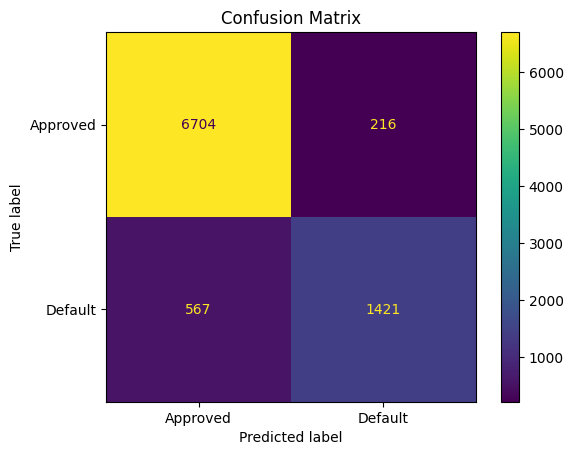

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Start simple — a shallow tree
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluate
print(classification_report(y_test, y_pred, 
      target_names=['Approved', 'Default']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
    display_labels=['Approved', 'Default'])
plt.title('Confusion Matrix')
plt.savefig('./output/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Now read your actual numbers:

- 567 false negatives — real defaulters the model said were fine. The bank approves their loan. They don't repay. Money lost. This is the expensive mistake.

- 216 false positives — good borrowers the model flagged as risky. The bank rejects their loan. The borrower is annoyed, the bank loses a customer. Embarrassing but not catastrophic.

In credit risk, false negatives cost more than false positives. That's why recall matters more than precision for the default class.

- Your model caught 71% of actual defaulters (recall = 0.71). That means it missed 29% of defaulters — that's your 567. For a first model with no tuning, that's decent. Not good enough for production, but decent.

- ROC-AUC of 0.945 means the model is very good at ranking borrowers by risk — it almost always gives a higher risk score to actual defaulters than to safe borrowers. That's the real signal.


In [14]:
# No depth limit — let it grow fully
model_full = DecisionTreeClassifier(random_state=42)
model_full.fit(X_train, y_train)

train_score = model_full.score(X_train, y_train)
test_score  = model_full.score(X_test, y_test)

print(f"Full tree — Train accuracy: {train_score:.3f}")
print(f"Full tree — Test accuracy:  {test_score:.3f}")

# Compare with your shallow tree
model_shallow = DecisionTreeClassifier(max_depth=4, random_state=42)
model_shallow.fit(X_train, y_train)

print(f"\nShallow tree — Train accuracy: {model_shallow.score(X_train, y_train):.3f}")
print(f"Shallow tree — Test accuracy:  {model_shallow.score(X_test, y_test):.3f}")

Full tree — Train accuracy: 1.000
Full tree — Test accuracy:  0.905

Shallow tree — Train accuracy: 0.910
Shallow tree — Test accuracy:  0.912


In [15]:
import pandas as pd

# What features did the tree find most useful?
feature_importance = pd.Series(
    model_shallow.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

previous_loan_defaults_on_file    0.495364
loan_percent_income               0.208903
loan_int_rate                     0.167451
person_income                     0.070675
person_home_ownership_RENT        0.050509
person_home_ownership_OWN         0.007097
person_gender                     0.000000
person_age                        0.000000
loan_amnt                         0.000000
person_education                  0.000000
dtype: float64


|--- previous_loan_defaults_on_file <= 0.50
|   |--- loan_percent_income <= 0.24
|   |   |--- loan_int_rate <= 13.99
|   |   |   |--- person_income <= 24587.50
|   |   |   |   |--- class: 1
|   |   |   |--- person_income >  24587.50
|   |   |   |   |--- class: 0
|   |   |--- loan_int_rate >  13.99
|   |   |   |--- person_home_ownership_OWN <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- person_home_ownership_OWN >  0.50
|   |   |   |   |--- class: 0
|   |--- loan_percent_income >  0.24
|   |   |--- person_home_ownership_RENT <= 0.50
|   |   |   |--- person_income <= 25127.00
|   |   |   |   |--- class: 1
|   |   |   |--- person_income >  25127.00
|   |   |   |   |--- class: 0
|   |   |--- person_home_ownership_RENT >  0.50
|   |   |   |--- loan_percent_income <= 0.25
|   |   |   |   |--- class: 1
|   |   |   |--- loan_percent_income >  0.25
|   |   |   |   |--- class: 1
|--- previous_loan_defaults_on_file >  0.50
|   |--- class: 0



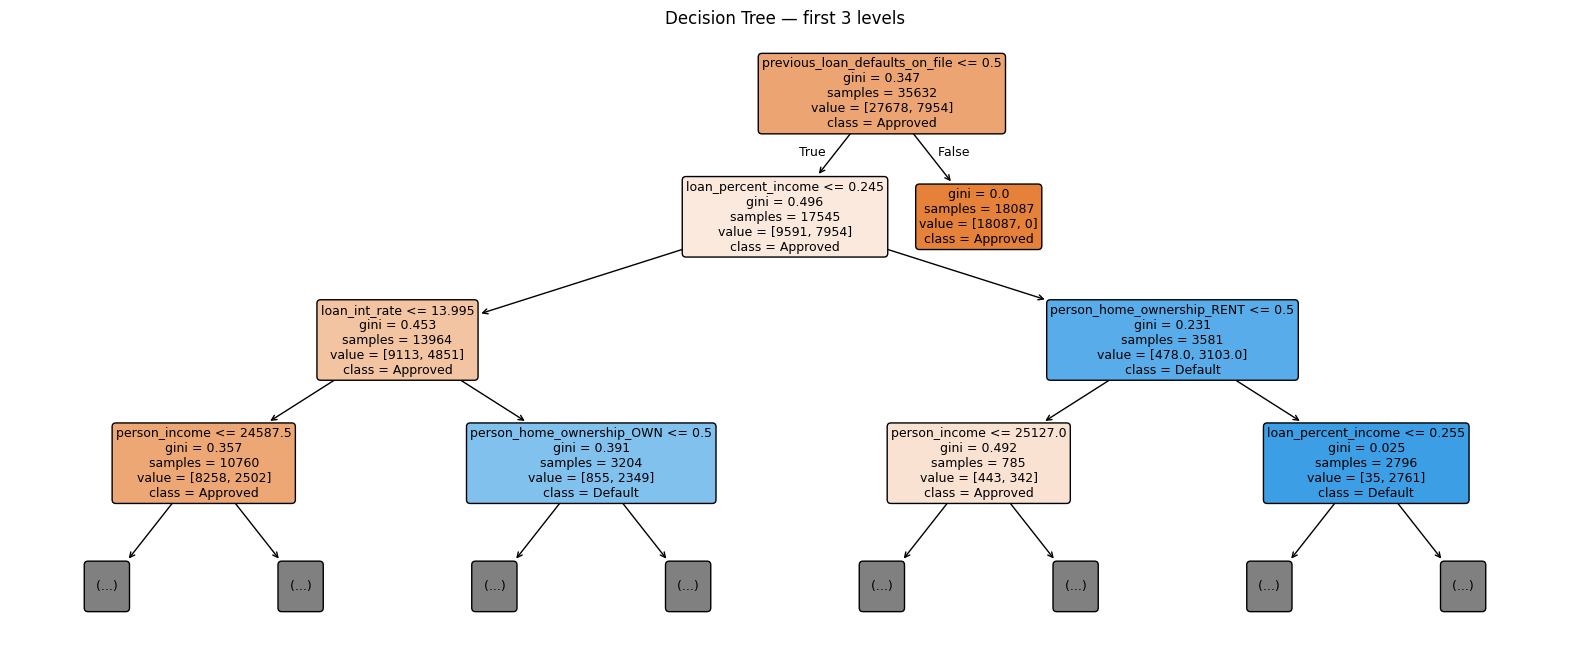

In [16]:
from sklearn.tree import export_text, plot_tree

# Text version — readable rules
rules = export_text(model_shallow, 
                    feature_names=list(X_train.columns))
print(rules)

# Visual version
plt.figure(figsize=(20, 8))
plot_tree(model_shallow,
          feature_names=X_train.columns,
          class_names=['Approved', 'Default'],
          filled=True, rounded=True,
          max_depth=3, fontsize=9)
plt.title('Decision Tree — first 3 levels')
plt.savefig('./output/decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

model_rf = RandomForestClassifier(n_estimators=100, random_state=42, 
                                   class_weight='balanced', n_jobs=1)
model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)
y_prob = model_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Approved', 'Default']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")

              precision    recall  f1-score   support

    Approved       0.94      0.98      0.96      6920
     Default       0.90      0.77      0.83      1988

    accuracy                           0.93      8908
   macro avg       0.92      0.87      0.89      8908
weighted avg       0.93      0.93      0.93      8908

ROC-AUC: 0.975


Walk-forward CV

In [19]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

# Walk-forward CV: train on past, test on future (expanding window)
# Rows treated as time-ordered (earliest → latest by index)
X_ordered = X.reset_index(drop=True)
y_ordered = y.reset_index(drop=True)

tscv = TimeSeriesSplit(n_splits=5)
wf_scores = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_ordered)):
    X_tr, X_te = X_ordered.iloc[train_idx], X_ordered.iloc[test_idx]
    y_tr, y_te = y_ordered.iloc[train_idx], y_ordered.iloc[test_idx]
    
    m = RandomForestClassifier(n_estimators=100, random_state=42,
                                class_weight="balanced", n_jobs=1)
    m.fit(X_tr, y_tr)
    score = roc_auc_score(y_te, m.predict_proba(X_te)[:, 1])
    wf_scores.append(score)
    print(f"Fold {fold+1}: Train rows={len(train_idx):>5}, Test rows={len(test_idx):>5} | ROC-AUC={score:.3f}")

wf_scores = np.array(wf_scores)
print(f"Walk-Forward CV ROC-AUC: {wf_scores.mean():.3f} ± {wf_scores.std():.3f}")
print("(Each fold trains on all past data and tests on next unseen chunk)")

Fold 1: Train rows= 7425, Test rows= 7423 | ROC-AUC=0.959
Fold 2: Train rows=14848, Test rows= 7423 | ROC-AUC=0.967
Fold 3: Train rows=22271, Test rows= 7423 | ROC-AUC=0.965
Fold 4: Train rows=29694, Test rows= 7423 | ROC-AUC=0.959
Fold 5: Train rows=37117, Test rows= 7423 | ROC-AUC=0.980
Walk-Forward CV ROC-AUC: 0.966 ± 0.008
(Each fold trains on all past data and tests on next unseen chunk)


SHAP

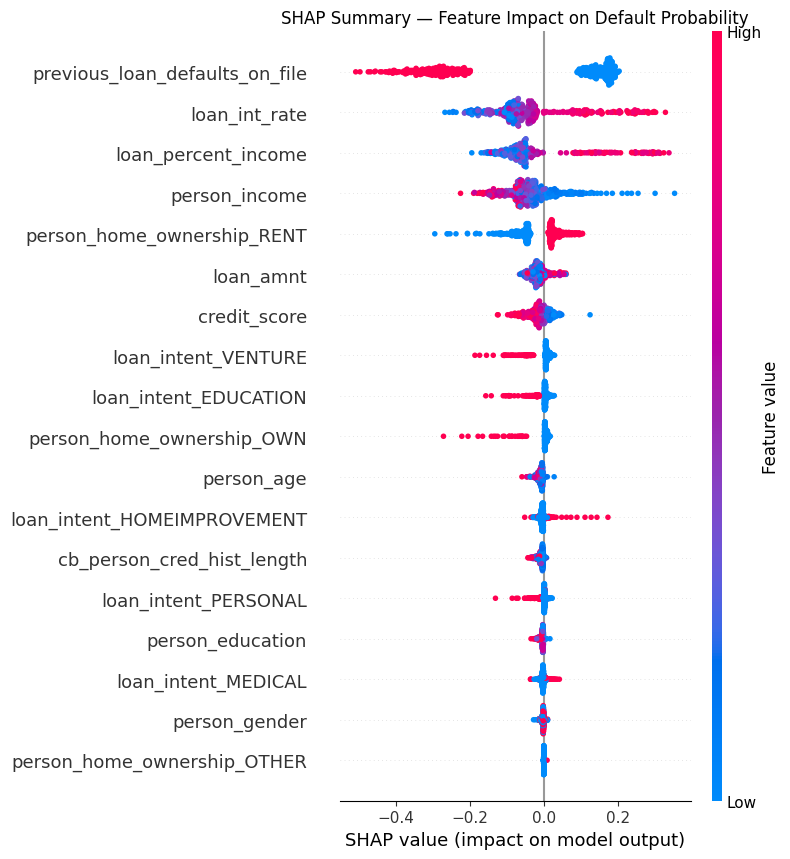

Top 10 features by mean |SHAP|:
previous_loan_defaults_on_file    0.223559
loan_int_rate                     0.097243
loan_percent_income               0.091916
person_income                     0.060450
person_home_ownership_RENT        0.052254
loan_amnt                         0.022228
credit_score                      0.022058
loan_intent_VENTURE               0.017315
loan_intent_EDUCATION             0.011109
person_home_ownership_OWN         0.010744
dtype: float64


In [ ]:
import shap
import matplotlib.pyplot as plt

X_sample = X_test.sample(500, random_state=42)

explainer = shap.TreeExplainer(model_rf)
shap_values = explainer.shap_values(X_sample)

# Summary plot — global feature importance
shap.summary_plot(shap_values[:, :, 1], X_sample, show=False)
plt.title("SHAP Summary — Feature Impact on Default Probability")
plt.tight_layout()
plt.savefig("./output/shap_summary.png", dpi=100, bbox_inches="tight")
plt.show()

# Save per-feature mean SHAP for API use
import pandas as pd
mean_shap = pd.Series(
    np.abs(shap_values[:, :, 1]).mean(axis=0),
    index=X_sample.columns
).sort_values(ascending=False)
print("Top 10 features by mean |SHAP|:")
print(mean_shap.head(10))

In [21]:
import joblib
# Save the model
joblib.dump(model_rf, 'model.pkl')
print("Model saved.")

Model saved.


In [22]:
print(list(X_train.columns))


['person_age', 'person_gender', 'person_education', 'person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']
